## **1. Instalasi Library (Jalankan Paling Awal)**

In [6]:
!pip install langchain langchain-core langchain-community langchain-groq langchain-huggingface pypdf faiss-cpu huggingface_hub sentence-transformers nltk pandas evaluate

## **2. Inisialisasi API Key & Model**

In [ ]:
import os
import nltk
from huggingface_hub import login

# Download tokenizers untuk keperluan BLEU score
nltk.download('punkt')
nltk.download('punkt_tab')

# 1. PENGATURAN API KEY GROQ
os.environ["GROQ_API_KEY"] = "MAsukkin api key Groq-mu di sini"

# 2. PENGATURAN API KEY HUGGING FACE
# Mengisi environment variable sekaligus melakukan login resmi ke HF Hub
HF_TOKEN = "Masukkan api key Hugging Face-mu di sini"
os.environ["HUGGINGFACEHUB_API_TOKEN"] = HF_TOKEN
login(token=HF_TOKEN, add_to_git_credential=False)

print("\nKEDUA API KEY (Groq & Hugging Face) berhasil dikonfigurasi dan aktif!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.



KEDUA API KEY (Groq & Hugging Face) berhasil dikonfigurasi dan aktif!


## **3. Fungsi Pembuat Prompt (Prompt Template)**

In [97]:
from langchain_core.prompts import PromptTemplate

def get_prompt_template(tingkat_kesulitan, tipe_soal, jumlah_soal, topik_terpakai="Belum ada"):
    if tingkat_kesulitan.upper() == "HOTS":
        panduan_kognitif = """Wajib Menggunakan Level Kognitif HOTS (C4/C5/C6):
- DILARANG KERAS menggunakan kata tanya berbasis hafalan baku seperti "Apa yang dimaksud", "Apa pengertian", atau kalimat berujung "adalah".
- WAJIB menyediakan STIMULUS nyata: studi kasus industri, skenario dilematis, cuplikan data/persentase, atau troubleshooting eror sistem.
- Pertanyaan harus memaksa siswa melakukan analisis komparatif, mendiagnosis masalah, atau mengevaluasi keputusan terbaik."""
    else:
        panduan_kognitif = """Wajib Menggunakan Level Kognitif LOTS (C1/C2/C3):
- Fokus pada pengujian ingatan, pemahaman dasar konsep, fungsi fitur, komponen, atau fakta literal yang tertulis di materi."""

    template = f"""Anda adalah seorang Profesor Senior Pembuat Soal Ujian Akademik dan Pakar Psikometri tingkat tinggi. Task Anda adalah merancang {jumlah_soal} butir soal ujian berkategori {tingkat_kesulitan} dengan tipe "{tipe_soal}" berdasarkan secara ketat hanya pada Konteks Materi yang disediakan.

{panduan_kognitif}

Panduan Kualitas Penjelasan & Semantic:
- Untuk key "alasan", jelaskan konsep dengan kata-kata Anda sendiri, pastikan mudah dipahami, dan berikan alasan yang **komprehensif namun padat**.
- Prioritaskan kejelasan dan presisi dalam alasan, sintetis dari informasi kontekstual yang relevan.
- Pastikan jawaban secara akurat mencerminkan pemahaman mendalam tentang konsep, bukan hanya pengulangan frasa dari teks sumber.

Aturan Validasi Format & Proteksi Redundansi Mutlak:
1. JAWABAN HARUS BERUPA VALID JSON ARRAY SAJA, tanpa teks pembuka, tanpa teks penutup, dan tanpa markdown block seperti ```json.
2. Setiap objek dalam array harus memiliki key wajib dengan huruf kecil: "no", "tipe", "tingkat", "soal", "pilihan", "kunci", "alasan", "sumber_halaman", dan "topik_bahasan".
3. Pada key "topik_bahasan", isi dengan 1 atau 2 kata kunci/istilah teknis inti (ditulis dengan huruf kecil) yang menjadi fokus utama soal yang Anda buat ini.
4. Jika tipe berupa "Pilihan Ganda (PG)", key "pilihan" wajib memiliki sub-key "A", "B", "C", "D". Jika tipe berupa "Isian Singkat" atau "Benar atau Salah", key "pilihan" wajib bernilai null.

⚠️ ATURAN ANTI-DUPLIKASI MUTLAK:
Topik/istilah teknis berikut ini SUDAH digunakan sebelumnya: [{topik_terpakai}].
Anda DILARANG KERAS membuat soal yang membahas atau berfokus pada istilah/topik yang ada di dalam daftar tersebut! Cari sub-bab, frasa kalimat, atau fungsionalitas lain dari Konteks Materi yang benar-benar belum tersentuh.

Konteks Materi:
{{context}}

Output JSON Array:"""
    return PromptTemplate(input_variables=["context"], template=template)

print("Prompt Siap")

Prompt Siap


## **4. Pipeline RAG Otomatis & Ekstraksi PDF (Fleksibel)**

In [81]:
import os
from google.colab import files
from langchain_groq import ChatGroq
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

print("Klik tombol di bawah untuk mengunggah berkas PDF materi Anda:")
uploaded = files.upload()

if not uploaded:
    raise ValueError("Proses dibatalkan. Anda harus mengunggah berkas PDF.")

nama_file_pdf = list(uploaded.keys())[0]
print(f"Berhasil mengunggah file: {nama_file_pdf}\n")

print("Melakukan ekstraksi teks dan pembagian chunk PDF...")
loader = PyPDFLoader(nama_file_pdf)
docs_raw = loader.load()

text_splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=200)
chunks = text_splitter.split_documents(docs_raw)
print(f"PDF berhasil dipecah menjadi {len(chunks)} chunk.")

print("Membangun database FAISS Vector Store menggunakan Hugging Face Embedding...")
embeddings_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vector_store = FAISS.from_documents(documents=chunks, embedding=embeddings_model)

# Konfigurasi Retriever & LLM Utama
retriever = vector_store.as_retriever(search_kwargs={"k": 8})
llm = ChatGroq(model_name="llama-3.1-8b-instant", temperature=0.1)

# Deteksi Topik Utama Otomatis
print("AI sedang mendeteksi topik utama dari isi PDF Anda...")
sampel_materi = docs_raw[0].page_content[:1000]
prompt_detektor = f"Baca teks berikut dan berikan 2 atau 3 kata kunci topik utamanya saja tanpa basa-basi: {sampel_materi}"
topik_otomatis = llm.invoke(prompt_detektor).content.strip()
print(f"Topik PDF Terdeteksi: '{topik_otomatis}'")
print("\nINISIALISASI RAG SELESAI! SIlakan berlanjut ke Cell berikutnya untuk membuat soal.")

Klik tombol di bawah untuk mengunggah berkas PDF materi Anda:


Saving materi-nlp.pdf to materi-nlp (5).pdf
Berhasil mengunggah file: materi-nlp (5).pdf

Melakukan ekstraksi teks dan pembagian chunk PDF...
PDF berhasil dipecah menjadi 225 chunk.
Membangun database FAISS Vector Store menggunakan Hugging Face Embedding...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

AI sedang mendeteksi topik utama dari isi PDF Anda...
Topik PDF Terdeteksi: 'NLP, Teknologi Bahasa Alami'

INISIALISASI RAG SELESAI! SIlakan berlanjut ke Cell berikutnya untuk membuat soal.


## **5. Generate Soal**

In [98]:
import re
import json
from langchain_core.output_parsers import StrOutputParser

print("🎬 Memulai Generator Paket Soal Skala Produksi (Metode Hemat Token)...")

daftar_kombinasi = [
    {"tipe": "Pilihan Ganda (PG)", "tingkat": "LOTS"},
    {"tipe": "Pilihan Ganda (PG)", "tingkat": "HOTS"},
    {"tipe": "Isian Singkat", "tingkat": "LOTS"},
    {"tipe": "Isian Singkat", "tingkat": "HOTS"},
    {"tipe": "Benar atau Salah", "tingkat": "LOTS"},
    {"tipe": "Benar atau Salah", "tingkat": "HOTS"}
]

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# Menarik dokumen referensi dari FAISS
docs_konteks = retriever.invoke(topik_otomatis)
context_text = format_docs(docs_konteks)

semua_soal_terbuat = []
daftar_topik_terpakai = []  # Memori pelacak topik global
nomor_urut = 1

for kombinasi in daftar_kombinasi:
    tipe_saat_ini = kombinasi["tipe"]
    tingkat_saat_ini = kombinasi["tingkat"]

    string_topik_terpakai = ", ".join(daftar_topik_terpakai) if daftar_topik_terpakai else "Belum ada"

    print(f"AI sedang menyusun Soal No {nomor_urut}: [{tipe_saat_ini} - {tingkat_saat_ini}]...")

    prompt_template = get_prompt_template(
        tingkat_kesulitan=tingkat_saat_ini,
        tipe_soal=tipe_saat_ini,
        jumlah_soal=1,
        topik_terpakai=string_topik_terpakai
    )

    rag_chain = (
        {"context": lambda x: context_text}
        | prompt_template
        | llm
        | StrOutputParser()
    )

    # Eksekusi RAG tunggal (Hemat Kuota)
    raw_output = rag_chain.invoke({})

    match = re.search(r'\[\s*\{.*\}\s*\]', raw_output, re.DOTALL)
    json_clean = match.group(0) if match else raw_output

    try:
        data_soal = json.loads(json_clean)
        for item in data_soal:
            item["no"] = nomor_urut
            semua_soal_terbuat.append(item)

            # MEMORY TRACKING LANGSUNG DARI KEY JSON AI
            topik_dari_ai = item.get("topik_bahasan", "").strip().lower()
            if topik_dari_ai:
                daftar_topik_terpakai.append(topik_dari_ai)

            nomor_urut += 1

    except Exception as e:
        print(f"Gagal memproses Soal No {nomor_urut}: {str(e)}")
        nomor_urut += 1

# ============================================================================
# TAMPILKAN HASIL AKHIR MURNI JSON
# ============================================================================
print("\n====================== HASIL GENERATOR PAKET SOAL MURNI JSON ======================")
print(json.dumps(semua_soal_terbuat, indent=2, ensure_ascii=False))
print("========================================================================================\n")

🎬 Memulai Generator Paket Soal Skala Produksi (Metode Hemat Token)...
AI sedang menyusun Soal No 1: [Pilihan Ganda (PG) - LOTS]...
AI sedang menyusun Soal No 2: [Pilihan Ganda (PG) - HOTS]...
AI sedang menyusun Soal No 3: [Isian Singkat - LOTS]...
AI sedang menyusun Soal No 4: [Isian Singkat - HOTS]...
AI sedang menyusun Soal No 5: [Benar atau Salah - LOTS]...
AI sedang menyusun Soal No 6: [Benar atau Salah - HOTS]...

====================== HASIL GENERATOR PAKET SOAL MURNI JSON ======================
[
  {
    "no": 1,
    "tipe": "Pilihan Ganda (PG)",
    "tingkat": "C1",
    "soal": "Apa yang dimaksud dengan pengambilan makna kontekstual dalam NLP?",
    "pilihan": {
      "A": "Pengambilan makna kontekstual adalah proses memahami makna kata atau frasa dalam konteks yang lebih luas.",
      "B": "Pengambilan makna kontekstual adalah proses mengganti kata-kata dalam bahasa sumber dengan kata-kata setara dalam bahasa target.",
      "C": "Pengambilan makna kontekstual adalah proses me

### Unduh Soal dalam Berbagai Format (dari Notebook)

In [112]:
# Instalasi library tambahan jika belum terinstal
!pip install xlsxwriter fpdf > /dev/null

import json
import pandas as pd
from google.colab import files
from fpdf import FPDF

print("Library untuk ekspor file siap.")

Library untuk ekspor file siap.


#### Unduh sebagai JSON

In [113]:
json_filename = 'soal_ujian.json'
with open(json_filename, 'w', encoding='utf-8') as f:
    json.dump(semua_soal_terbuat, f, indent=2, ensure_ascii=False)
files.download(json_filename)
print(f"Soal berhasil diekspor ke {json_filename}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Soal berhasil diekspor ke soal_ujian.json


#### Unduh sebagai Excel (.xlsx)

In [114]:
df_soal = pd.DataFrame(semua_soal_terbuat)
excel_filename = 'soal_ujian.xlsx'
df_soal.to_excel(excel_filename, index=False, engine='xlsxwriter')
files.download(excel_filename)
print(f"Soal berhasil diekspor ke {excel_filename}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Soal berhasil diekspor ke soal_ujian.xlsx


#### Unduh sebagai Teks Biasa (.txt)

In [115]:
txt_filename = 'soal_ujian.txt'
with open(txt_filename, 'w', encoding='utf-8') as f:
    for index, row in df_soal.iterrows():
        f.write(f"No Soal: {row['no']}\n")
        f.write(f"Tipe Soal: {row['tipe']} ({row['tingkat']})\n")
        f.write(f"Pertanyaan: {row['soal']}\n")
        if isinstance(row['pilihan'], dict):
            f.write("Pilihan Jawaban:\n")
            for key, value in row['pilihan'].items():
                f.write(f"  {key}. {value}\n")
        elif row['pilihan'] is not None:
            f.write(f"Pilihan: {row['pilihan']}\n")
        f.write(f"Kunci Jawaban: {row['kunci']}\n")
        f.write(f"Alasan: {row['alasan']}\n")
        f.write(f"Sumber Halaman: {row['sumber_halaman']}\n")
        f.write(f"Topik Bahasan: {row['topik_bahasan']}\n")
        f.write("\n" + "="*50 + "\n\n") # Pemisah antar soal
files.download(txt_filename)
print(f"Soal berhasil diekspor ke {txt_filename}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Soal berhasil diekspor ke soal_ujian.txt


#### Unduh sebagai PDF

## **6. Evaluasi (Semantic Similarity & BLEU Score)**

In [99]:
import pandas as pd
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from sentence_transformers import SentenceTransformer, util


print("Memulai Evaluasi Kualitas Soal yang Telah Terbuat...")

if not semua_soal_terbuat:
    print("Eror: Belum ada data soal di memori. Silakan jalankan Cell 5 terlebih dahulu!")
else:
    # 1. Menarik Ground Truth dasar dari FAISS
    docs_ground_truth = retriever.invoke(topik_otomatis)
    teks_ground_truth_gabungan = " ".join([doc.page_content for doc in docs_ground_truth])

    # Perbaikan BLEU: Pecah ground truth raksasa menjadi list kalimat-kalimat pendek
    list_kalimat_referensi = nltk.sent_tokenize(teks_ground_truth_gabungan.lower())
    ref_tokens_kumpulan = [nltk.word_tokenize(kalimat) for kalimat in list_kalimat_referensi]

    # 2. Inisialisasi model embedding untuk evaluasi semantik
    model_eval_embed = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

    hasil_evaluasi = []

    # EVALUASI DATA SOAL DARI MEMORI PYTHON
    for item in semua_soal_terbuat:
        nomor_soal = item.get("no")

        # Menggunakan nilai fallback jika AI lupa menuliskan key-nya di JSON
        tipe_soal = item.get("tipe") if item.get("tipe") else "Tidak Terdeteksi"
        tingkat_kesulitan = item.get("tingkat") if item.get("tingkat") else "Tidak Terdeteksi"

        pertanyaan = item.get("soal", "")
        alasan_ai = item.get("alasan", "")

        # --- 1. Perhitungan Semantic Similarity ---
        emb_ai = model_eval_embed.encode(alasan_ai, convert_to_tensor=True)
        emb_gt = model_eval_embed.encode(teks_ground_truth_gabungan, convert_to_tensor=True)
        semantic_score = util.cos_sim(emb_ai, emb_gt).item()

        # --- 2. Perhitungan BLEU Score (Perbaikan Strategi Match) ---
        cand_tokens = nltk.word_tokenize(alasan_ai.lower())
        chencherry = SmoothingFunction()

        # Menghitung BLEU dengan membandingkan candidate terhadap kumpulan kalimat referensi asli PDF
        # Menggunakan weights=(0.5, 0.5) untuk fokus pada 1-gram dan 2-gram (kecocokan kata tunggal & frasa dua kata)
        bleu_score = sentence_bleu(
            ref_tokens_kumpulan,
            cand_tokens,
            weights=(0.5, 0.5, 0, 0),
            smoothing_function=chencherry.method1
        )

        hasil_evaluasi.append({
            "No Soal": nomor_soal,
            "Tipe Soal": tipe_soal,
            "Tingkat Kesulitan": tingkat_kesulitan,
            "Pertanyaan": pertanyaan[:40] + "...",
            "Semantic Similarity": round(semantic_score, 4),
            "BLEU Score": round(bleu_score, 4)
        })

    # ============================================================================
    # TAMPILKAN TABEL EVALUASI METRIK BARU
    # ============================================================================
    print("\n========= TABEL EVALUASI KOMPREHENSIF METRIK (6 VARIASI SOAL) =========")
    df_hasil = pd.DataFrame(hasil_evaluasi)
    display(df_hasil)
    print("==========================================================================")

    print(f"\nRata-rata Akhir Semantic Similarity : {df_hasil['Semantic Similarity'].mean():.4f} (Ideal > 0.60)")
    print(f"Rata-rata Akhir BLEU Score          : {df_hasil['BLEU Score'].mean():.4f} (Kecocokan literal frasa kata)")

Memulai Evaluasi Kualitas Soal yang Telah Terbuat...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


========= TABEL EVALUASI KOMPREHENSIF METRIK (6 VARIASI SOAL) =========


,No Soal,Tipe Soal,Tingkat Kesulitan,Pertanyaan,Semantic Similarity,BLEU Score
0,1,Pilihan Ganda (PG),C1,Apa yang dimaksud dengan pengambilan mak...,0.5684,0.8478
1,2,Pilihan Ganda (PG),C5,Dalam konteks pengambilan makna kontekst...,0.6536,0.7439
2,3,Isian Singkat,C1,Apa yang dimaksud dengan pengambilan mak...,0.6201,0.8992
3,4,Isian Singkat,C5,"Dalam konteks NLP, apa yang dimaksud den...",0.6264,0.7767
4,5,Benar atau Salah,C1,Apa yang dimaksud dengan pengambilan mak...,0.6558,0.8466
5,6,Benar atau Salah,C5,Dalam konteks pengambilan makna kontekst...,0.5974,0.6788



Rata-rata Akhir Semantic Similarity : 0.6203 (Ideal > 0.60)
Rata-rata Akhir BLEU Score          : 0.7988 (Kecocokan literal frasa kata)


### Visualisasi Hasil Evaluasi

Untuk mempermudah analisis, mari kita visualisasikan perbandingan Semantic Similarity dan BLEU Score antara soal LOTS dan HOTS, serta antar tipe soal.

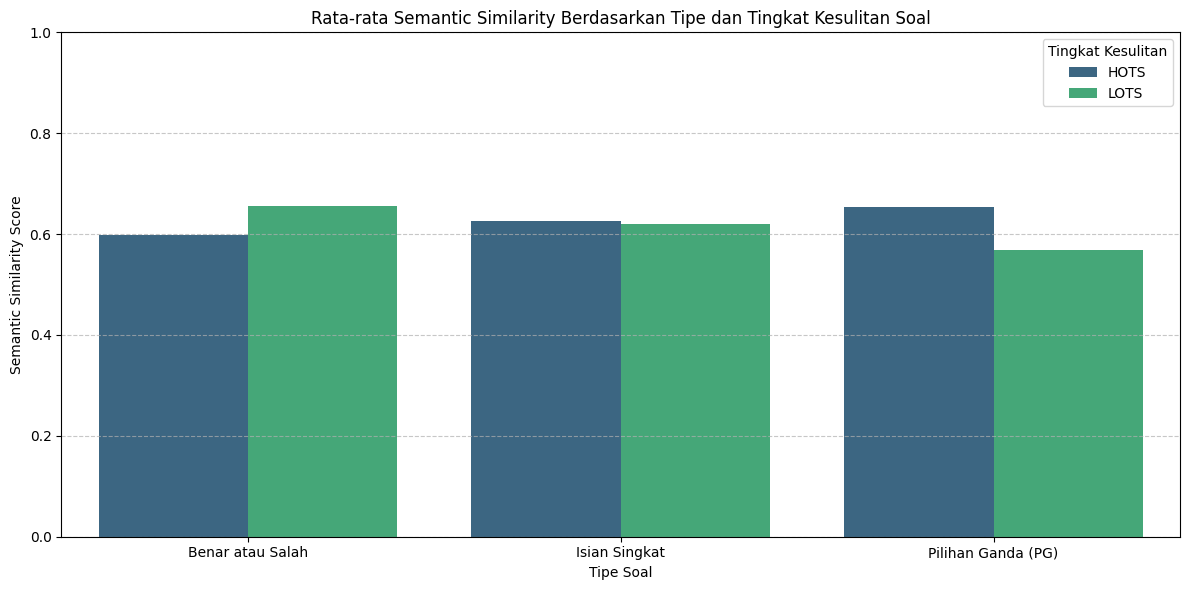

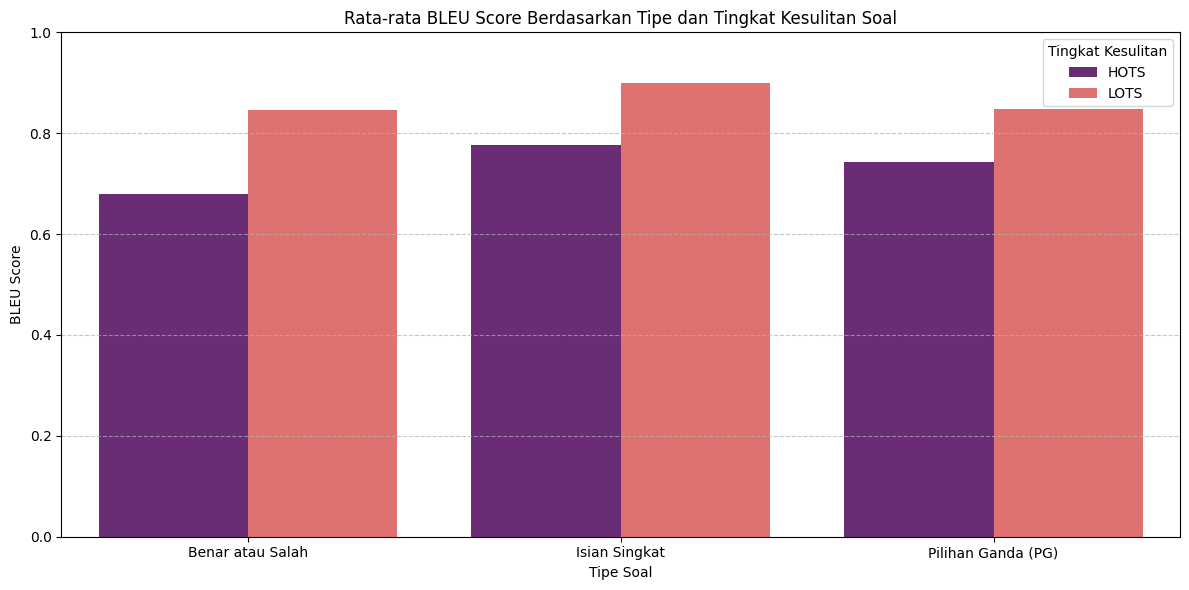

Visualisasi hasil evaluasi telah dibuat.


In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

# Memastikan kolom tingkat kesulitan sudah sesuai
df_hasil['Tingkat Kesulitan'] = df_hasil['Tingkat Kesulitan'].str.replace('C1', 'LOTS').str.replace('C2', 'LOTS').str.replace('C3', 'LOTS').str.replace('C4', 'HOTS').str.replace('C5', 'HOTS').str.replace('C6', 'HOTS')

# Agregasi data untuk visualisasi
df_agg_plot = df_hasil.groupby(['Tipe Soal', 'Tingkat Kesulitan'])[['Semantic Similarity', 'BLEU Score']].mean().reset_index()

# --- Visualisasi ---

# Plotting Semantic Similarity
plt.figure(figsize=(12, 6))
sns.barplot(x='Tipe Soal', y='Semantic Similarity', hue='Tingkat Kesulitan', data=df_agg_plot, palette='viridis')
plt.title('Rata-rata Semantic Similarity Berdasarkan Tipe dan Tingkat Kesulitan Soal')
plt.ylabel('Semantic Similarity Score')
plt.ylim(0, 1) # Skor biasanya antara 0 dan 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plotting BLEU Score
plt.figure(figsize=(12, 6))
sns.barplot(x='Tipe Soal', y='BLEU Score', hue='Tingkat Kesulitan', data=df_agg_plot, palette='magma')
plt.title('Rata-rata BLEU Score Berdasarkan Tipe dan Tingkat Kesulitan Soal')
plt.ylabel('BLEU Score')
plt.ylim(0, 1) # Skor biasanya antara 0 dan 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Visualisasi hasil evaluasi telah dibuat.")

### Interpretasi Visualisasi

Dari grafik di atas, Anda bisa menganalisis:

*   **Perbandingan LOTS vs HOTS:** Apakah ada perbedaan yang jelas dalam Semantic Similarity dan BLEU Score antara soal-soal LOTS dan HOTS untuk setiap tipe soal? Idealnya, soal HOTS mungkin memiliki Semantic Similarity yang lebih tinggi (menunjukkan pemahaman konsep yang lebih dalam), sementara BLEU Score bisa bervariasi tergantung pada seberapa 'langsung' jawaban yang diharapkan.
*   **Kecenderungan per Tipe Soal:** Bagaimana performa masing-masing tipe soal (Pilihan Ganda, Isian Singkat, Benar atau Salah) dalam hal kedua metrik?

Analisis ini akan membantu Anda menilai apakah penyesuaian `prompt_template` Anda sudah berhasil mendorong AI untuk menghasilkan soal yang lebih sesuai dengan target tingkat kognitif.

## **7. File untuk Deployment ke Hugging Face Spaces**

### `app.py`

In [102]:
%%writefile app.py

import os
import json
import re
import nltk
import pandas as pd
from fpdf import FPDF
import io

import gradio as gr

from langchain_groq import ChatGroq
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
# from sentence_transformers import SentenceTransformer, util # Not directly used in app for generation

# --- 0. Konfigurasi API Keys dan Model ---
# NLTK downloads (ensure these are available in the environment)
try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    nltk.download('punkt')
try:
    nltk.data.find('tokenizers/punkt_tab')
except nltk.downloader.DownloadError:
    nltk.download('punkt_tab')

# Get API keys from environment variables (for Hugging Face Spaces Secrets)
GROQ_API_KEY = os.environ.get("GROQ_API_KEY")
HF_TOKEN = os.environ.get("HUGGINGFACEHUB_API_TOKEN")

if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY environment variable not set. Please set it as a Space Secret.")
if not HF_TOKEN:
    raise ValueError("HUGGINGFACEHUB_API_TOKEN environment variable not set. Please set it as a Space Secret.")

# Initialize LLM
llm = ChatGroq(model_name="llama-3.1-8b-instant", temperature=0.1, groq_api_key=GROQ_API_KEY)

# Initialize Hugging Face Embeddings
# For simplicity in deployment, we'll initialize directly from model_name
embeddings_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2", huggingfacehub_api_token=HF_TOKEN)


# --- 1. Fungsi Pembuat Prompt (dari notebook) ---
def get_prompt_template(tingkat_kesulitan, tipe_soal, jumlah_soal, topik_terpakai="Belum ada"):
    if tingkat_kesulitan.upper() == "HOTS":
        panduan_kognitif = """Wajib Menggunakan Level Kognitif HOTS (C4/C5/C6):
- DILARANG KERAS menggunakan kata tanya berbasis hafalan baku seperti "Apa yang dimaksud", "Apa pengertian", atau kalimat berujung "adalah".
- WAJIB menyediakan STIMULUS nyata: studi kasus industri, skenario dilematis, cuplikan data/persentase, atau troubleshooting eror sistem.
- Pertanyaan harus memaksa siswa melakukan analisis komparatif, mendiagnosis masalah, atau mengevaluasi keputusan terbaik."""
    else:
        panduan_kognitif = """Wajib Menggunakan Level Kognitif LOTS (C1/C2/C3):
- Fokus pada pengujian ingatan, pemahaman dasar konsep, fungsi fitur, komponen, atau fakta literal yang tertulis di materi."""

    template = f"""Anda adalah seorang Profesor Senior Pembuat Soal Ujian Akademik dan Pakar Psikometri tingkat tinggi. Task Anda adalah merancang {jumlah_soal} butir soal ujian berkategori {tingkat_kesulitan} dengan tipe "{tipe_soal}" berdasarkan secara ketat hanya pada Konteks Materi yang disediakan.

{panduan_kognitif}

Panduan Kualitas Penjelasan & Semantic:
- Untuk key "alasan", jelaskan konsep dengan kata-kata Anda sendiri, pastikan mudah dipahami, dan berikan alasan yang **komprehensif namun padat**.
- Prioritaskan kejelasan dan presisi dalam alasan, sintetis dari informasi kontekstual yang relevan.
- Pastikan jawaban secara akurat mencerminkan pemahaman mendalam tentang konsep, bukan hanya pengulangan frasa dari teks sumber.

Aturan Validasi Format & Proteksi Redundansi Mutlak:
1. JAWABAN HARUS BERUPA VALID JSON ARRAY SAJA, tanpa teks pembuka, tanpa teks penutup, dan tanpa markdown block seperti ```json.
2. Setiap objek dalam array harus memiliki key wajib dengan huruf kecil: "no", "tipe", "tingkat", "soal", "pilihan", "kunci", "alasan", "sumber_halaman", dan "topik_bahasan".
3. Pada key "topik_bahasan", isi dengan 1 atau 2 kata kunci/istilah teknis inti (ditulis dengan huruf kecil) yang menjadi fokus utama soal yang Anda buat ini.
4. Jika tipe berupa "Pilihan Ganda (PG)", key "pilihan" wajib memiliki sub-key "A", "B", "C", "D". Jika tipe berupa "Isian Singkat" atau "Benar atau Salah", key "pilihan" wajib bernilai null.

⚠️ ATURAN ANTI-DUPLIKASI MUTLAK:
Topik/istilah teknis berikut ini SUDAH digunakan sebelumnya: [{topik_terpakai}].
Anda DILARANG KERAS membuat soal yang membahas atau berfokus pada istilah/topik yang ada di dalam daftar tersebut! Cari sub-bab, frasa kalimat, atau fungsionalitas lain dari Konteks Materi yang benar-benar belum tersentuh.

Konteks Materi:
{{context}}

Output JSON Array:"""
    return PromptTemplate(input_variables=["context"], template=template)

# --- 2. Fungsi Utama untuk Generate Soal ---
def generate_questions(pdf_file_obj, selected_combinations_json_str):
    if pdf_file_obj is None:
        return gr.Dataframe.update(value=None), gr.File.update(value=None), gr.File.update(value=None), \
               gr.File.update(value=None), gr.File.update(value=None), "Silakan unggah file PDF."

    # Gradio File object provides name and read() method
    pdf_path = pdf_file_obj.name

    # --- RAG Pipeline (from notebook) ---
    loader = PyPDFLoader(pdf_path)
    docs_raw = loader.load()

    text_splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=200)
    chunks = text_splitter.split_documents(docs_raw)

    vector_store = FAISS.from_documents(documents=chunks, embedding=embeddings_model)
    retriever = vector_store.as_retriever(search_kwargs={"k": 8})

    # Auto detect main topic
    sampel_materi = docs_raw[0].page_content[:1000] # Use first 1000 chars of first doc
    prompt_detektor = f"Baca teks berikut dan berikan 2 atau 3 kata kunci topik utamanya saja tanpa basa-basi: {sampel_materi}"
    topik_otomatis = llm.invoke(prompt_detektor).content.strip()

    # Menarik dokumen referensi dari FAISS
    docs_konteks = retriever.invoke(topik_otomatis)
    context_text = "\n\n".join(doc.page_content for doc in docs_konteks)

    # --- Question Generation (from notebook) ---
    semua_soal_terbuat = []
    daftar_topik_terpakai = []
    nomor_urut = 1

    # Parse selected combinations from JSON string
    selected_combinations = json.loads(selected_combinations_json_str)

    for kombinasi in selected_combinations:
        tipe_saat_ini = kombinasi["tipe"]
        tingkat_saat_ini = kombinasi["tingkat"]

        string_topik_terpakai = ", ".join(daftar_topik_terpakai) if daftar_topik_terpakai else "Belum ada"

        prompt_template = get_prompt_template(
            tingkat_kesulitan=tingkat_saat_ini,
            tipe_soal=tipe_saat_ini,
            jumlah_soal=1,
            topik_terpakai=string_topik_terpakai
        )

        rag_chain = (
            {"context": lambda x: context_text}
            | prompt_template
            | llm
            | StrOutputParser()
        )

        raw_output = rag_chain.invoke({})

        # Extract JSON array from potential extra text (e.g., markdown ```json or other chat text)
        match = re.search(r'\[\s*\{.*\}\s*\]', raw_output, re.DOTALL)
        json_clean = match.group(0) if match else raw_output

        try:
            data_soal = json.loads(json_clean)
            for item in data_soal:
                item["no"] = nomor_urut
                semua_soal_terbuat.append(item)

                # MEMORY TRACKING LANGSUNG DARI KEY JSON AI
                topik_dari_ai = item.get("topik_bahasan", "").strip().lower()
                if topik_dari_ai and topik_dari_ai not in daftar_topik_terpakai:
                    daftar_topik_terpakai.append(topik_dari_ai)

                nomor_urut += 1
        except json.JSONDecodeError as e:
            print(f"Error decoding JSON for question {nomor_urut} ({tipe_saat_ini}-{tingkat_saat_ini}): {e}")
            print(f"Raw output: {raw_output[:500]}...") # Log part of the problematic output
        except Exception as e:
            print(f"Other error processing question {nomor_urut}: {str(e)}")

    if not semua_soal_terbuat:
        return gr.Dataframe.update(value=None), gr.File.update(value=None), gr.File.update(value=None), \
               gr.File.update(value=None), gr.File.update(value=None), "Tidak ada soal yang berhasil dibuat. Coba lagi atau sesuaikan prompt."

    df_soal = pd.DataFrame(semua_soal_terbuat)
    return gr.Dataframe.update(value=df_soal), \
           gr.File.update(value=generate_json_output(semua_soal_terbuat), visible=True), \
           gr.File.update(value=generate_excel_output(df_soal), visible=True), \
           gr.File.update(value=generate_txt_output(df_soal), visible=True), \
           gr.File.update(value=generate_pdf_output(df_soal), visible=True), \
           "Soal berhasil dibuat dan siap diunduh!"

# --- 3. Fungsi untuk Ekspor Data (menggunakan BytesIO untuk Gradio File output) ---
def generate_json_output(data):
    buffer = io.BytesIO()
    buffer.write(json.dumps(data, indent=2, ensure_ascii=False).encode('utf-8'))
    buffer.seek(0)
    return buffer

def generate_excel_output(df):
    buffer = io.BytesIO()
    df.to_excel(buffer, index=False, engine='xlsxwriter')
    buffer.seek(0)
    return buffer

def generate_txt_output(df):
    buffer = io.BytesIO()
    # Using TextIOWrapper to handle encoding for writing strings to a bytes buffer
    with io.TextIOWrapper(buffer, encoding='utf-8') as writer:
        for index, row in df.iterrows():
            for col, value in row.items():
                writer.write(f"{col}: {value}\n")
            writer.write("\n" + "="*50 + "\n\n") # Pemisah antar soal
    buffer.seek(0)
    return buffer

def generate_pdf_output(df):
    class PDF(FPDF):
        def header(self):
            self.set_font('DejaVu', '', 12)
            self.cell(0, 10, 'Soal Ujian Generator AI', 0, 1, 'C')
            self.ln(10)

        def footer(self):
            self.set_y(-15)
            self.set_font('DejaVu', '', 8)
            self.cell(0, 10, f'Page {self.page_no()}', 0, 0, 'C')

    pdf = PDF()
    # Ensure DejaVuSansCondensed.ttf is available in the Hugging Face Space environment
    # This path is common in Linux-based environments.
    pdf.add_font('DejaVu', '', '/usr/share/fonts/truetype/dejavu/DejaVuSansCondensed.ttf', uni=True)
    pdf.set_font('DejaVu', '', 10)
    pdf.add_page()
    pdf.set_auto_page_break(auto=True, margin=15)

    for index, row in df.iterrows():
        pdf.multi_cell(0, 5, f"No Soal: {row['no']}")
        pdf.multi_cell(0, 5, f"Tipe Soal: {row['tipe']} ({row['tingkat']})")
        pdf.multi_cell(0, 5, f"Pertanyaan: {row['soal']}")

        if 'pilihan' in row and row['pilihan'] is not None:
            if isinstance(row['pilihan'], dict):
                pdf.multi_cell(0, 5, "Pilihan Jawaban:")
                for key, value in row['pilihan'].items():
                    pdf.multi_cell(0, 5, f"  {key}. {value}")
            else:
                pdf.multi_cell(0, 5, f"Pilihan: {row['pilihan']}")

        pdf.multi_cell(0, 5, f"Kunci Jawaban: {row['kunci']}")
        pdf.multi_cell(0, 5, f"Alasan: {row['alasan']}")
        pdf.multi_cell(0, 5, f"Sumber Halaman: {row['sumber_halaman']}")
        pdf.multi_cell(0, 5, f"Topik Bahasan: {row['topik_bahasan']}")
        pdf.ln(5) # Spasi antar soal

    buffer = io.BytesIO()
    pdf.output(buffer, 'S') # 'S' for string, returns bytes
    buffer.seek(0)
    return buffer

# --- 4. Gradio Interface ---
# Define all possible combinations for CheckboxGroup
all_combinations = [
    {"tipe": "Pilihan Ganda (PG)", "tingkat": "LOTS"},
    {"tipe": "Pilihan Ganda (PG)", "tingkat": "HOTS"},
    {"tipe": "Isian Singkat", "tingkat": "LOTS"},
    {"tipe": "Isian Singkat", "tingkat": "HOTS"},
    {"tipe": "Benar atau Salah", "tingkat": "LOTS"},
    {"tipe": "Benar atau Salah", "tingkat": "HOTS"}
]

# Create display strings and a map back to dicts
display_combinations = [f"{c['tipe']} ({c['tingkat']})" for c in all_combinations]
combination_map = {f"{c['tipe']} ({c['tingkat']})": c for c in all_combinations}


def process_and_generate_gradio(pdf_file, selected_display_combinations):
    # Convert selected display strings back to original dict format
    actual_selected_combinations = [combination_map[s] for s in selected_display_combinations]

    # Call the core generation function with the PDF file and combinations as JSON string
    # Gradio File components pass their value as a file object when used as input
    return generate_questions(pdf_file, json.dumps(actual_selected_combinations))


with gr.Blocks() as demo:
    gr.Markdown("# 🤖 AI-Powered Question Generator from PDF")
    gr.Markdown("Unggah file PDF materi Anda, lalu pilih kombinasi tipe dan tingkat kesulitan soal yang ingin Anda buat.")

    with gr.Row():
        pdf_input = gr.File(label="Unggah File PDF Materi", type="file")
        question_types = gr.CheckboxGroup(
            label="Pilih Tipe & Tingkat Kesulitan Soal",
            choices=display_combinations,
            value=display_combinations, # All selected by default
            info="Pilih kombinasi tipe soal dan tingkat kesulitan yang diinginkan. Soal akan dibuat untuk setiap kombinasi yang dipilih."
        )

    generate_btn = gr.Button("🚀 Buat Soal")

    output_status = gr.Textbox(label="Status Proses", interactive=False)
    question_dataframe = gr.Dataframe(label="Soal yang Dibuat", interactive=False)

    gr.Markdown("--- ")
    gr.Markdown("### Unduh Soal dalam Berbagai Format")
    with gr.Row():
        json_output = gr.File(label="Unduh JSON", file_count="single", interactive=False, visible=False)
        excel_output = gr.File(label="Unduh Excel", file_count="single", interactive=False, visible=False)
        txt_output = gr.File(label="Unduh TXT", file_count="single", interactive=False, visible=False)
        pdf_output = gr.File(label="Unduh PDF", file_count="single", interactive=False, visible=False)

    generate_btn.click(
        process_and_generate_gradio,
        inputs=[pdf_input, question_types],
        outputs=[question_dataframe, json_output, excel_output, txt_output, pdf_output, output_status]
    )

demo.launch(debug=True, share=True)


Writing app.py


### `requirements.txt` (Daftar Dependensi)


In [103]:
%%writefile requirements.txt

langchain
langchain-core
langchain-community
langchain-groq
langchain-huggingface
pypdf
faiss-cpu
huggingface_hub
sentence-transformers
nltk
pandas
evaluate
gradio # For the UI
fpdf # For PDF export
xlsxwriter # For Excel export


Writing requirements.txt


### `README.md` (Gambaran Aplikasi)

In [110]:
%%writefile README.md

---
title: {{title}}
emoji: {{emoji}}
colorFrom: {{colorFrom}}
colorTo: {{colorTo}}
sdk: {{sdk}}
sdk_version: "{{sdkVersion}}"
{{#pythonVersion}}
python_version: "{{pythonVersion}}"
{{/pythonVersion}}
app_file: app.py
pinned: false
---

Check out the configuration reference at https://huggingface.co/docs/hub/spaces-config-reference

# Generator Soal Otomatis Bertenaga AI dari PDF

Hugging Face Space ini menghadirkan aplikasi bertenaga AI yang menghasilkan soal ujian dari dokumen PDF apa pun yang diunggah. Memanfaatkan pipeline Retrieval Augmented Generation (RAG) dengan LLM Groq dan embedding Hugging Face, sistem ini dapat membuat soal dengan berbagai tipe (Pilihan Ganda, Isian Singkat, Benar/Salah) dan tingkat kesulitan kognitif (LOTS - Lower-Order Thinking Skills, HOTS - Higher-Order Thinking Skills).

## Fitur:
-   **Unggah PDF**: Unggah materi kuliah Anda atau dokumen apa pun dalam format PDF.
-   **Generasi Soal Cerdas**: AI memproses PDF, mengekstrak informasi kunci, dan menghasilkan soal berdasarkan konten.
-   **Tipe Soal yang Dapat Dikonfigurasi**: Pilih dari soal Pilihan Ganda, Isian Singkat, atau Benar/Salah.
-   **Tingkat Kesulitan yang Dapat Dikonfigurasi**: Hasilkan soal yang disesuaikan untuk LOTS (mengingat, pemahaman) atau HOTS (analisis, evaluasi, sintesis).
-   **Mekanisme Anti-Duplikasi**: Memastikan soal mencakup subtopik yang beragam dari dokumen.
-   **Berbagai Format Ekspor**: Unduh soal yang dihasilkan dalam format JSON, Excel (.xlsx), Teks Biasa (.txt), atau PDF.

## Cara Penggunaan:
1.  **Unggah PDF Anda**: Klik tombol "Unggah File PDF Materi" dan pilih file PDF Anda.
2.  **Pilih Kombinasi Soal**: Pilih kombinasi tipe dan tingkat kesulitan soal yang diinginkan (misalnya, "Pilihan Ganda (PG) (LOTS)", "Isian Singkat (HOTS)"). Semua dipilih secara default.
3.  **Hasilkan Soal**: Klik tombol "🚀 Buat Soal". AI akan memproses PDF Anda dan menghasilkan soal.
4.  **Tinjau & Unduh**: Soal yang dihasilkan akan muncul dalam tabel. Anda kemudian dapat mengunduhnya dalam format pilihan Anda menggunakan tombol unduh yang disediakan.

## Dokumentasi UI:
Proyek ini mencakup antarmuka pengguna yang dibuat dengan Gradio. UI menyediakan cara intuitif untuk berinteraksi dengan sistem pembuatan soal AI. Komponen kunci dan fungsinya adalah:
-   **Input File**: Memungkinkan pengguna untuk mengunggah dokumen PDF.
-   **Grup Kotak Centang (Checkbox Group)**: Memungkinkan pemilihan tipe soal dan tingkat kesulitan yang diinginkan.
-   **Tombol Hasilkan (Generate Button)**: Memicu proses pembuatan soal.
-   **Status Output**: Menampilkan status proses pembuatan saat ini.
-   **Dataframe Soal**: Menampilkan soal yang dihasilkan dalam format tabel.
-   **Tombol Unduh (Download Buttons)**: Menyediakan opsi untuk mengunduh soal dalam format JSON, Excel, TXT, dan PDF.

## Detail Teknis:
-   **LLM**: `llama-3.1-8b-instant` dari Groq untuk generasi soal.
-   **Embeddings**: `sentence-transformers/all-MiniLM-L6-v2` dari Hugging Face untuk membuat embedding vektor.
-   **Vector Store**: FAISS untuk pencarian kesamaan yang efisien.
-   **Framework**: LangChain untuk mengatur pipeline RAG.
-   **Antarmuka Pengguna**: Gradio.

## Catatan Deployment:
Aplikasi ini berjalan di Hugging Face Spaces. Pastikan `GROQ_API_KEY` dan `HUGGINGFACEHUB_API_TOKEN` telah diatur sebagai Space Secrets agar aplikasi berfungsi dengan benar.

Overwriting README.md


In [111]:
from google.colab import files

files.download('app.py')
files.download('requirements.txt')
files.download('README.md')

print("File-file telah disiapkan untuk diunduh.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File-file telah disiapkan untuk diunduh.
